# Forecasting GDP Growth
This project tasks you with forecasting quarterly nominal GDP growth rate in the United States. The dataset contains estimated nominal gross domestic product (GDP) annual growth rate in each quarter from 1990 to 2020, released by the Bureau of Economic Analysis (BEA) of the United States Department of Commerce. The estimate is the “third” or "final" estimate of GDP issued in the third month after the relevant quarter which is based on more complete source data than were available for the "second" estimate issued in the second month and the "advance" estimate issued in the first month after the relevant quarter. You may refer to the [BEA website](https://www.bea.gov/resources/learning-center/what-to-know-gdp) for more information on the estimate of GDP in the United States. You will train models to forecast the BEA's final GDP estimate for a quarter. Specifically you are required to answer this question: Is accounting information useful for GDP forecast? You will be allowed to use any outside data to build your model.

The evaluation pages describes how submissions will be scored and how students should format their submissions. --- The evaluation metric for this competition is [RMSE](https://en.wikipedia.org/wiki/Root-mean-square_deviation). RMSE is a measure of the accuracy of your predictions.

**Files**
- GDP_Forecast_train.csv - the training set
- GDP_Forecast_test.csv - the test set
- GDP_Forecast_sampleSubmission.csv - a sample submission file in the correct format

**Columns**
- YQ - The year and quarter variable. 1990Q1 refers to the first calendar quarter of 1990, ie, Jan - March 1990
- NGDP - nominal GDP growth rate in the quarter of the year. It is obtained from the BEA final estimate which is available at the BEA website.

**Features** (no features data provided)

Following Datar et al. (2020), you may consider the following data as your predictors/features:
- Accounting data - through COMPUSTAT on WRDS
- Stock price/return data - through CRSP on WRDS
- Analysts' forecast of GDP - through Survey of Professional Forecasters
- Any other data

In [1]:
## IMPORT

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error # perform mean-squared for RMSE
from statsmodels.stats.anova import anova_lm                        # perform Chi-Squared test
import statsmodels.formula.api as smf                               # for OLS (smf.ols)
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

## IGNORE WARNINGS

warnings.filterwarnings("ignore")

## LOAD DATA

# 1. base data
train = pd.read_csv("data/GDP_Forecast_train.csv")
test = pd.read_csv("data/GDP_Forecast_test.csv")
gdp_pca = pd.read_csv("data/GDP_PCA_for_test.csv")  # validation data for test
# 2. non-financial external indicators
indpro = pd.read_csv("data/INDPRO_PC1.csv")
unrate = pd.read_csv("data/UNRATE_CH1.csv")
# 3. financial external indicators
compustat = pd.read_csv("data/compustat_quarterly_financials2.csv")

### Data Preparation

This section helps to standardise the representation of `year` and `quarter` in dataset. The original data stores time in a quarterly string format (e.g. "1990Q1") under the `YQ` column.

In [2]:
## CONVERT YEAR-QUARTER: SPLIT COLUMNS

# ensure year is an integer
train["year"] = train["YQ"].str[:4].astype(int)
test["year"] = test["YQ"].str[:4].astype(int)
# keep qtr as string / category
train["qtr"] = train["YQ"].str[4:]
test["qtr"] = test["YQ"].str[4:]

## CONVERT TO COMMON QUARTER KEY - to confirm if we need

train["quarter"] = pd.PeriodIndex(train["YQ"], freq = "Q")
test["quarter"]  = pd.PeriodIndex(test["YQ"],  freq = "Q")

The GDP_PCA dataset is used for validation purposes. The original `observation_date` variable is converted into a pandas datetime format to extract the `year` and `quarter` values to align with the quarterly structure of the forecasting data.

Importantly, the GDP_PCA variable is not used as a predictor in the forecasting model; instead, it serves as an external proxy for economic activity that is later used to evaluate the accuracy of the model’s predicted NGDP growth.

In [3]:
## USING SEPARATE gdp_pca DATASET FOR gdp_pcaING RMSE
# we are using a different dataset for gdp_pca because we want to calculate RMSE before submitting

# convert the data to YQ, year and quarter
gdp_pca["observation_date"] = pd.to_datetime(gdp_pca["observation_date"], dayfirst = True)
gdp_pca["year"] = gdp_pca["observation_date"].dt.year
gdp_pca["qtr"] = "Q" + gdp_pca["observation_date"].dt.quarter.astype(str)
gdp_pca["YQ"] = gdp_pca["year"].astype(str) + gdp_pca["qtr"]
# remove observation_date column and move GDP to the back while changing col name to NGDP
gdp_pca.drop(columns = "observation_date", inplace = True)
col = gdp_pca.pop("GDP_PCA")
gdp_pca["NGDP"] = col
# get the quarterly
gdp_pca.sort_values(by = "YQ")
# # check data for 1990 - 2015 is similar to train to continue with this dataset for gdp_pca
# gdp_pca[gdp_pca["year"] <= 2015].transpose()
## NOTE: data from later years is not as accurate, but we will use this to tentatively gdp_pca our RMSE
gdp_pca = gdp_pca[gdp_pca["year"]>= 2016].reset_index(drop = True)

## PREVIEWING OF GDP_PCA (VALIDATION ONLY)

print("GDP_PCA preview:")
print(gdp_pca.head(8))
print(gdp_pca.tail(8))
print("\nGDP_PCA info:")
print("Number of rows:", len(gdp_pca))
print("Number of unique quarters:", gdp_pca["YQ"].nunique())
print("Any missing YQ?", gdp_pca["YQ"].isna().any())
print("Any missing GDP_PCA?", gdp_pca["NGDP"].isna().any())
print("\nCheck duplicate quarters in GDP_PCA:", gdp_pca["YQ"].duplicated().sum())

GDP_PCA preview:
   year qtr      YQ  NGDP
0  2016  Q1  2016Q1   2.0
1  2016  Q2  2016Q2   4.1
2  2016  Q3  2016Q3   3.9
3  2016  Q4  2016Q4   4.2
4  2017  Q1  2017Q1   4.1
5  2017  Q2  2017Q2   3.3
6  2017  Q3  2017Q3   5.3
7  2017  Q4  2017Q4   7.2
    year qtr      YQ  NGDP
12  2019  Q1  2019Q1   3.8
13  2019  Q2  2019Q2   5.5
14  2019  Q3  2019Q3   6.1
15  2019  Q4  2019Q4   4.0
16  2020  Q1  2020Q1  -3.3
17  2020  Q2  2020Q2 -29.1
18  2020  Q3  2020Q3  39.9
19  2020  Q4  2020Q4   7.2

GDP_PCA info:
Number of rows: 20
Number of unique quarters: 20
Any missing YQ? False
Any missing GDP_PCA? False

Check duplicate quarters in GDP_PCA: 0


### Defining Functions
This section defines functions needed for:
- Calculating the performance between 2 models based off its Adjusted R-Squared and Chi-Squared values
- Creating a submission for Kaggle using the `YQ` and its predicted NGDP (`y_pred`)

In [4]:
## DEFINE FUNCTIONS FOR REUSE

def calc_performance(formula1, model1, formula2, model2):
    print(pd.DataFrame({'model'   : [formula1, formula2],
                    'Adj.R^2' : [model1.rsquared_adj, model2.rsquared_adj]}))
    print()
    print(anova_lm(model1, model2, test = "Chisq"))

def create_submission(test_df, y_pred, filename):
    df = pd.DataFrame({"YQ": test_df["YQ"], "NGDP": y_pred})
    df.to_csv(f"attempts/{filename}.csv", index = False)

### Base Model
This section creates a base model on the `train` set, forecasts NGDP using the model on the `test` set, and validates the model against our validation set `GDP_PCA`.

In [5]:
## CREATE LAG VARIABLE

# sort training data by quarter before creating lag
train = train.sort_values(by = "quarter").reset_index(drop = True)
# create 1-quarter lag of NGDP
train["NGDP_lag1"] = train["NGDP"].shift(1)
# remove first row with missing lag
train = train.dropna().copy()

## FIT BASE MODEL

formula_base = "NGDP ~ NGDP_lag1"
model_base = smf.ols(formula_base, data=train).fit()
print(model_base.summary())

                            OLS Regression Results                            
Dep. Variable:                   NGDP   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     24.00
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           3.68e-06
Time:                        01:32:56   Log-Likelihood:                -237.24
No. Observations:                 103   AIC:                             478.5
Df Residuals:                     101   BIC:                             483.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.5247      0.479      5.273      0.0

From the base model, it is recognised that when NGDP_lag1 = 0, GDP Growth Rate is predicted to be 2.52%. This is the baseline growth rate the model assumes independent of last quarter's GDP. For every 1 percentage point increase in last quarter's GDP Growth Rate, this quarter's GDP growth increases by 0.44 percentage points.

In [6]:
## RECURSIVE FORECASTING USING BASE MODEL
# use last observed NGDP from training set as the starting lag

# sort training data by quarter
test = test.sort_values(by = "quarter").reset_index(drop = True)
# storing forecasts
base_forecast = []
# getting final quarter NGDP in train as the first quarter NGDP lag in train
last_ngdp = train["NGDP"].iloc[-1]

for i in range(len(test)):
    # building X_new with column names matching what the model was trained on
    X_new = pd.DataFrame({
        "const"     : [1],
        "NGDP_lag1" : [last_ngdp]
    })
    # predicts model on X_new
    pred = model_base.predict(X_new)[0]
    # store prediction to base_forecast
    base_forecast.append(pred)
    # update lag for next quarter
    last_ngdp = pred
    
# add predictions to test set
test["base_forecast"] = base_forecast

## PREVIEW FORECAST RESULTS

print("Base forecast preview:")
print(test[["YQ", "base_forecast"]].head(8))
print(test[["YQ", "base_forecast"]].tail(8))

Base forecast preview:
       YQ  base_forecast
0  2016Q1       2.743384
1  2016Q2       3.724569
2  2016Q3       4.153708
3  2016Q4       4.341400
4  2017Q1       4.423491
5  2017Q2       4.459395
6  2017Q3       4.475098
7  2017Q4       4.481966
        YQ  base_forecast
12  2019Q1       4.487220
13  2019Q2       4.487268
14  2019Q3       4.487289
15  2019Q4       4.487298
16  2020Q1       4.487302
17  2020Q2       4.487304
18  2020Q3       4.487304
19  2020Q4       4.487305


When conducting validation, we will work with RMSE and MAE:

- While RMSE squares the errors before averaging, so large errors are penalised disproportionately
- We use MAE because it treats all errors equally regardless of size

By using both measures, if RMSE is significantly larger than MAE, we can detect that the model consists of large errors even though the model is reasonably accurate most of the time. If RMSE value is close to MAE value, it would suggest that the model errors are consistently spread across all quarters.

This is particularly relevant for our dataset as shock periods like the 2008 Financial Crisis and 2020 COVID-19 Pandemic are likely to produce large prediction errors in isolated quarters, inflating RMSE while MAE remains moderate.

`The base model produces forecasts that converge rapidly to a stable long-run level, reflecting the autoregressive persistence structure of the model. While the model performs reasonably during relatively stable periods, it fails to capture the sharp contraction and rebound in 2020, leading to a comparatively high RMSE. This suggests that lagged NGDP alone is insufficient for modelling substantial macroeconomic fluctuations, thereby motivating the introduction of external leading indicators in the subsequent specification.`

In [7]:
## VALIDATE BASE MODEL FORECAST AGAINST GDP_PCA

# keep only the predicted values needed for validation
base_validation = test[["YQ", "base_forecast"]].merge(
    gdp_pca[["YQ", "NGDP"]],
    on = "YQ",
    how = "left"
)

# rename columns clearly
base_validation.rename(columns = {
    "base_forecast" : "NGDP_pred",
    "NGDP"          : "NGDP_actual"
}, inplace = True)


## CALCULATE PERFORMANCE METRICS (RMSE AND MAE)

# calculating rmse - measure of accuracy for Kaggle submission
rmse_base = np.sqrt(mean_squared_error(
    base_validation["NGDP_actual"],
    base_validation["NGDP_pred"]
))

# calculating mae - measures average absolute difference between true and predicted value
mae_base = mean_absolute_error(
    base_validation["NGDP_actual"],
    base_validation["NGDP_pred"]
)

print("Base model RMSE:", round(rmse_base, 4))
print("Base model MAE :", round(mae_base, 4))


## PREVIEW VALIDATION TABLE

print("\nBase validation preview:")
print(base_validation.head(8))
print(base_validation.tail(8))
print("\nAny missing actual values?", base_validation["NGDP_actual"].isna().any())
print("Any missing predicted values?", base_validation["NGDP_pred"].isna().any())

Base model RMSE: 11.1175
Base model MAE : 4.7121

Base validation preview:
       YQ  NGDP_pred  NGDP_actual
0  2016Q1   2.743384          2.0
1  2016Q2   3.724569          4.1
2  2016Q3   4.153708          3.9
3  2016Q4   4.341400          4.2
4  2017Q1   4.423491          4.1
5  2017Q2   4.459395          3.3
6  2017Q3   4.475098          5.3
7  2017Q4   4.481966          7.2
        YQ  NGDP_pred  NGDP_actual
12  2019Q1   4.487220          3.8
13  2019Q2   4.487268          5.5
14  2019Q3   4.487289          6.1
15  2019Q4   4.487298          4.0
16  2020Q1   4.487302         -3.3
17  2020Q2   4.487304        -29.1
18  2020Q3   4.487304         39.9
19  2020Q4   4.487305          7.2

Any missing actual values? False
Any missing predicted values? False


Insights: With the base model having a RMSE of 11.1175 and MAE of 4.7121, it confirms that the model does not perform well on shock periods. This is also proven with 2020Q2 where the predicted NGDP Growth Rate remains at 4.487304, while the actual NGDP Growth Rate was -29.1.

### Model with Non-Financial External Indicators
This section creates a macro indicator model on the `train` set using non-financial external data, forecasts NGDP using the model on the `test` set, and validates the model against our validation set `GDP_PCA`.

In [8]:
## CONVERT NON-FINANCIAL EXTERNAL INDICATORS TO COMMON QUARTER FORMAT

# convert observation_date to datetime
indpro["observation_date"] = pd.to_datetime(indpro["observation_date"])
unrate["observation_date"] = pd.to_datetime(unrate["observation_date"])
# create year and quarter columns
indpro["year"] = indpro["observation_date"].dt.year
unrate["year"] = unrate["observation_date"].dt.year
indpro["qtr"] = "Q" + indpro["observation_date"].dt.quarter.astype(str)
unrate["qtr"] = "Q" + unrate["observation_date"].dt.quarter.astype(str)
# create YQ key
indpro["YQ"] = indpro["year"].astype(str) + indpro["qtr"]
unrate["YQ"] = unrate["year"].astype(str) + unrate["qtr"]
# sort chronologically
indpro = indpro.sort_values(by = "YQ").reset_index(drop = True)
unrate = unrate.sort_values(by = "YQ").reset_index(drop = True)

## PREVIEW NON-FINANCIAL INDICATORS

print("\nINDPRO preview:")
print(indpro.head(6))
print(indpro.tail(6))
print("\nUNRATE preview:")
print(unrate.head(6))
print(unrate.tail(6))


INDPRO preview:
  observation_date  INDPRO_PC1  year qtr      YQ
0       1989-10-01    -0.14565  1989  Q4  1989Q4
1       1990-01-01     0.13001  1990  Q1  1990Q1
2       1990-04-01     1.20008  1990  Q2  1990Q2
3       1990-07-01     2.22277  1990  Q3  1990Q3
4       1990-10-01     0.25080  1990  Q4  1990Q4
5       1991-01-01    -2.39237  1991  Q1  1991Q1
    observation_date  INDPRO_PC1  year qtr      YQ
119       2019-07-01    -1.48515  2019  Q3  2019Q3
120       2019-10-01    -2.26870  2019  Q4  2019Q4
121       2020-01-01    -3.00853  2020  Q1  2020Q1
122       2020-04-01   -14.64907  2020  Q2  2020Q2
123       2020-07-01    -6.49265  2020  Q3  2020Q3
124       2020-10-01    -4.22257  2020  Q4  2020Q4

UNRATE preview:
  observation_date  UNRATE_CH1  year qtr      YQ
0       1989-10-01         0.0  1989  Q4  1989Q4
1       1990-01-01         0.1  1990  Q1  1990Q1
2       1990-04-01         0.1  1990  Q2  1990Q2
3       1990-07-01         0.5  1990  Q3  1990Q3
4       1990-10-01   

insert explanation on construction of non-financial indicators

In [9]:
## CONSTRUCT NON-FINANCIAL INDICATORS AND UNEMPLOYMENT DYNAMIC FEATURES

# sort chronologically before creating lags
indpro = indpro.sort_values(by = "YQ").reset_index(drop = True)
unrate = unrate.sort_values(by = "YQ").reset_index(drop = True)

# industrial production lag
indpro["INDPRO_lag1"] = indpro["INDPRO_PC1"].shift(1)
# unemployment persistence
unrate["UNRATE_lag1"] = unrate["UNRATE_CH1"].shift(1)

# unemployment momentum
unrate["UNRATE_change"] = unrate["UNRATE_CH1"] - unrate["UNRATE_lag1"]
# positive unemployment shocks
unrate["UNRATE_spike"] = np.maximum(unrate["UNRATE_change"], 0)


## MERGE NON-FINANCIAL INDICATORS INTO TRAIN DATA

train_ext = train.copy()

# adding indpro data to external training set
train_ext = train_ext.merge(
    indpro[["YQ", "INDPRO_PC1", "INDPRO_lag1"]],
    on = "YQ",
    how = "left"
)

# adding unemployment data to external training set
train_ext = train_ext.merge(
    unrate[[
        "YQ", "UNRATE_CH1", "UNRATE_lag1",
        "UNRATE_change", "UNRATE_spike"
    ]],
    on = "YQ",
    how = "left"
)


## PREVIEW TRAIN DATA WITH EXTERNAL INDICATORS

print("Train_ext preview:")
print(train_ext.head(4))
print(train_ext.tail(4))
print("\nMissing values check:")
print("INDPRO_lag1 missing:", train_ext["INDPRO_lag1"].isna().sum())
print("UNRATE_lag1 missing:", train_ext["UNRATE_lag1"].isna().sum())
print("UNRATE_change missing:", train_ext["UNRATE_change"].isna().sum())
print("UNRATE_spike missing:", train_ext["UNRATE_spike"].isna().sum())

Train_ext preview:
       YQ  NGDP  year qtr quarter  NGDP_lag1  INDPRO_PC1  INDPRO_lag1  \
0  1990Q2   6.1  1990  Q2  1990Q2        9.0     1.20008      0.13001   
1  1990Q3   3.7  1990  Q3  1990Q3        6.1     2.22277      1.20008   
2  1990Q4  -0.7  1990  Q4  1990Q4        3.7     0.25080      2.22277   
3  1991Q1   2.0  1991  Q1  1991Q1       -0.7    -2.39237      0.25080   

   UNRATE_CH1  UNRATE_lag1  UNRATE_change  UNRATE_spike  
0         0.1          0.1            0.0           0.0  
1         0.5          0.1            0.4           0.4  
2         0.8          0.5            0.3           0.3  
3         1.3          0.8            0.5           0.5  
         YQ  NGDP  year qtr quarter  NGDP_lag1  INDPRO_PC1  INDPRO_lag1  \
99   2015Q1   3.1  2015  Q1  2015Q1        2.5     1.33495      3.18299   
100  2015Q2   4.6  2015  Q2  2015Q2        3.1    -1.40555      1.33495   
101  2015Q3   2.5  2015  Q3  2015Q3        4.6    -1.87240     -1.40555   
102  2015Q4   0.5  2015  

#### Fitting model using OLS on non-financial indicators

In [10]:
## FIT EXTENDED MODEL WITH NON-FINANCIAL INDICATORS AND UNEMPLOYMENT DYNAMICS

# remove observations with missing data
train_model_ext = train_ext.dropna(subset = [
    "NGDP", "NGDP_lag1",
    "INDPRO_PC1", "INDPRO_lag1",
    "UNRATE_change", "UNRATE_spike"
]).copy()

# designing model
formula_ext = """
NGDP ~ NGDP_lag1
     + INDPRO_PC1 + INDPRO_lag1
     + UNRATE_change + UNRATE_spike
"""

model_ext = smf.ols(formula_ext, data = train_model_ext).fit()
print(model_ext.summary())

                            OLS Regression Results                            
Dep. Variable:                   NGDP   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.497
Method:                 Least Squares   F-statistic:                     21.20
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           2.86e-14
Time:                        01:32:56   Log-Likelihood:                -210.19
No. Observations:                 103   AIC:                             432.4
Df Residuals:                      97   BIC:                             448.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         5.7294      0.607      9.437

In [11]:
## MERGE NON-FINANCIAL INDICATORS INTO TEST DATA

test_ext = test.copy()

# adding indpro data to external training set
test_ext = test_ext.merge(
    indpro[["YQ", "INDPRO_PC1", "INDPRO_lag1"]],
    on = "YQ",
    how = "left"
)

# adding unemployment data to external training set
test_ext = test_ext.merge(
    unrate[[
        "YQ", "UNRATE_CH1", "UNRATE_lag1",
        "UNRATE_change", "UNRATE_spike"
    ]],
    on = "YQ",
    how = "left"
)

test_ext = test_ext.sort_values(by = "quarter").reset_index(drop = True)


## PREVIEW TEST DATA WITH EXTERNAL INDICATORS

print("Test_ext preview:")
print(test_ext.head(8))
print(test_ext.tail(8))
print("\nMissing values check:")
print("INDPRO_lag1 missing:", test_ext["INDPRO_lag1"].isna().sum())
print("UNRATE_lag1 missing:", test_ext["UNRATE_lag1"].isna().sum())
print("UNRATE_change missing:", test_ext["UNRATE_change"].isna().sum())
print("UNRATE_spike missing:", test_ext["UNRATE_spike"].isna().sum())

Test_ext preview:
       YQ  NGDP  year qtr quarter  base_forecast  INDPRO_PC1  INDPRO_lag1  \
0  2016Q1     0  2016  Q1  2016Q1       2.743384    -3.28993     -3.75351   
1  2016Q2     0  2016  Q2  2016Q2       3.724569    -2.26259     -3.28993   
2  2016Q3     0  2016  Q3  2016Q3       4.153708    -2.11848     -2.26259   
3  2016Q4     0  2016  Q4  2016Q4       4.341400    -0.90597     -2.11848   
4  2017Q1     0  2017  Q1  2017Q1       4.423491    -0.26115     -0.90597   
5  2017Q2     0  2017  Q2  2017Q2       4.459395     1.54303     -0.26115   
6  2017Q3     0  2017  Q3  2017Q3       4.475098     1.01141      1.54303   
7  2017Q4     0  2017  Q4  2017Q4       4.481966     2.57450      1.01141   

   UNRATE_CH1  UNRATE_lag1  UNRATE_change  UNRATE_spike  
0        -0.6         -0.7            0.1           0.1  
1        -0.5         -0.6            0.1           0.1  
2        -0.2         -0.5            0.3           0.3  
3        -0.3         -0.2           -0.1           0.0 

In [12]:
## RECURSIVE FORECASTING WITH NON-FINANCIAL INDICATORS

ext_forecast = []
last_ngdp = train["NGDP"].iloc[-1]

for i in range(len(test_ext)):
    row = test_ext.iloc[i]  # getting current row data
    X_new = pd.DataFrame({
        "NGDP_lag1"     : [last_ngdp],              # NGDP_lag1 uses last_ngdp
        "INDPRO_PC1"    : [row["INDPRO_PC1"]],      # the rest uses the data constructed for this model
        "INDPRO_lag1"   : [row["INDPRO_lag1"]],
        "UNRATE_change" : [row["UNRATE_change"]],
        "UNRATE_spike"  : [row["UNRATE_spike"]]
    })
    pred = model_ext.predict(X_new)[0]
    ext_forecast.append(pred)
    last_ngdp = pred
    
test_ext["ext_forecast"] = ext_forecast

## PREVIEW FORECAST RESULTS

print("Extended model forecast preview:")
print(test_ext[["YQ", "ext_forecast"]].head(8))
print(test_ext[["YQ", "ext_forecast"]].tail(8))

Extended model forecast preview:
       YQ  ext_forecast
0  2016Q1      4.537811
1  2016Q2      4.600670
2  2016Q3      3.301665
3  2016Q4      5.275403
4  2017Q1      5.250554
5  2017Q2      5.237969
6  2017Q3      4.897642
7  2017Q4      6.787250
        YQ  ext_forecast
12  2019Q1      4.164216
13  2019Q2      3.291946
14  2019Q3      3.800177
15  2019Q4      3.930051
16  2020Q1      2.940512
17  2020Q2    -42.805738
18  2020Q3     -3.046765
19  2020Q4     -2.510806


In [13]:
## VALIDATE EXTENDED MODEL FORECAST AGAINST GDP_PCA

ext_validation = test_ext[["YQ","ext_forecast"]].merge(
    gdp_pca[["YQ","NGDP"]],
    on = "YQ", how = "left"
)

ext_validation.rename(columns = {
    "ext_forecast":"NGDP_pred",
    "NGDP":"NGDP_actual"
}, inplace = True)


## CALCULATE PERFORMANCE METRICS (RMSE AND MAE)

rmse_ext = np.sqrt(mean_squared_error(
    ext_validation["NGDP_actual"],
    ext_validation["NGDP_pred"]
))

mae_ext = mean_absolute_error(
    ext_validation["NGDP_actual"],
    ext_validation["NGDP_pred"]
)

print("Extended model RMSE:", round(rmse_ext,4))
print("Extended model MAE :", round(mae_ext,4))

Extended model RMSE: 10.4753
Extended model MAE : 4.4835


Insights: With the extended model, both the RMSE and MAE have dropped, but the divergence between the 2 measures suggests that the model still does not perform well on shock periods.

#### Defining stress regime

In [14]:
## DEFINE STRESS REGIME USING TRAINING DATA

# creating tmp_train using a copy of train_ext WITHOUT UNRATE_change
tmp_train = train_ext.dropna(subset=["UNRATE_change"]).copy()
# determine stress threshold from training sample (90th percentile)
spike_thr = tmp_train["UNRATE_change"].quantile(0.90)

if pd.isna(spike_thr):
    spike_thr = 0.4

def add_regime_flags(df, spike_thr):
    df_output = df.copy()
    # flagging quarters where unemployment jump is unusually large
    df_output["stress_flag"] = (
        df_output["UNRATE_change"] >= spike_thr
    ).astype(int)
    # interaction term
    df_output["stress_x_unrate_change"] = df_output["stress_flag"] * df_output["UNRATE_change"]
    return df_output

train_ext = add_regime_flags(train_ext, spike_thr)
test_ext  = add_regime_flags(test_ext, spike_thr)

print(train_ext[["YQ","UNRATE_change","stress_flag"]].head(8))
print(train_ext[["YQ","UNRATE_change","stress_flag"]].tail(8))
print(train_ext["stress_flag"].value_counts())

       YQ  UNRATE_change  stress_flag
0  1990Q2            0.0            0
1  1990Q3            0.4            1
2  1990Q4            0.3            1
3  1991Q1            0.5            1
4  1991Q2            0.2            0
5  1991Q3           -0.3            0
6  1991Q4           -0.2            0
7  1992Q1           -0.2            0
         YQ  UNRATE_change  stress_flag
95   2014Q1           -0.2            0
96   2014Q2           -0.2            0
97   2014Q3            0.1            0
98   2014Q4            0.0            0
99   2015Q1            0.1            0
100  2015Q2            0.3            1
101  2015Q3           -0.2            0
102  2015Q4            0.3            1
stress_flag
0    87
1    16
Name: count, dtype: int64


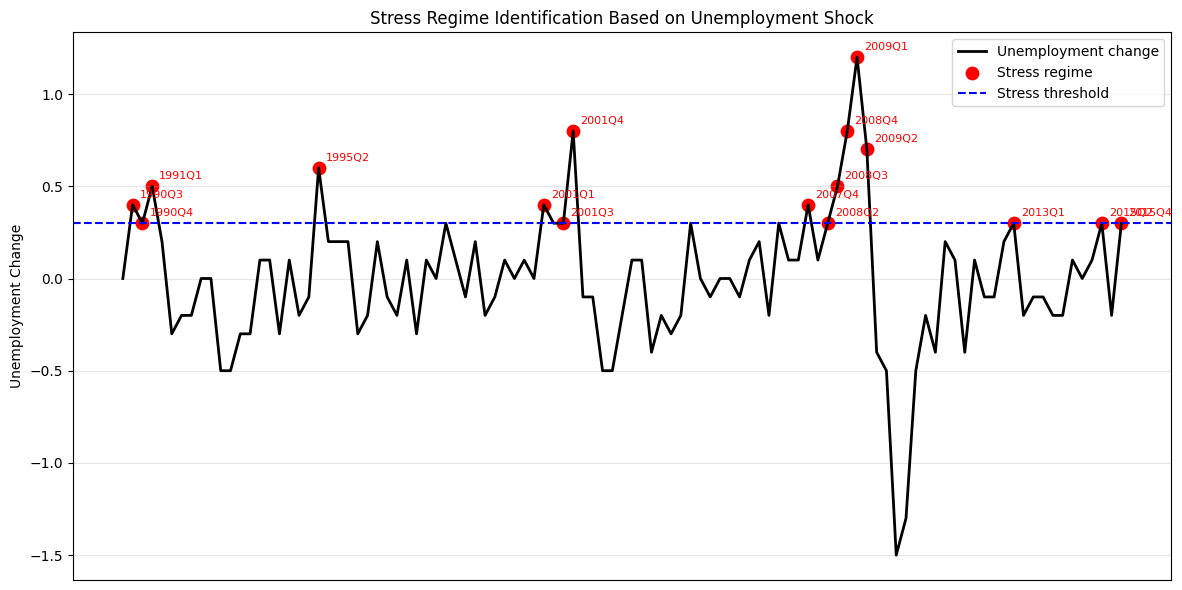

In [15]:
## VISUALISE STRESS REGIME BASED ON UNEMPLOYMENT CHANGE

plt.figure(figsize = (12,6))

# plot unemployment change
plt.plot(
    range(len(train_ext)),
    train_ext["UNRATE_change"],
    color="black",
    linewidth=2,
    label="Unemployment change"
)

# mark stress periods
stress_points = train_ext[train_ext["stress_flag"] == 1]
# plot (scatter) unemployment change stressors
plt.scatter(
    stress_points.index,
    stress_points["UNRATE_change"],
    color = "red",
    s = 80,
    label = "Stress regime"
)

# annotate only stress points with their YQ label
for idx, row in stress_points.iterrows():
    plt.annotate(
        row["YQ"],
        xy=(idx, row["UNRATE_change"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        color="red"
    )

# plot threshold line
plt.axhline(
    spike_thr,
    color = "blue",
    linestyle = "--",
    label = "Stress threshold"
)

plt.xticks([])
plt.xlabel("")
plt.ylabel("Unemployment Change")
plt.title("Stress Regime Identification Based on Unemployment Shock")
plt.legend()
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

#### Fitting model using OLS on non-financial indicators + stress regime

In [16]:
## FIT EXTENDED MODEL WITH NON-FINANCIAL INDICATORS AND STRESS REGIME

train_model_regime = train_ext.dropna(subset = [
    "NGDP", "NGDP_lag1",
    "INDPRO_PC1", "INDPRO_lag1",
    "UNRATE_change", "stress_flag"
]).copy()

formula_regime = """
NGDP ~ NGDP_lag1
     + INDPRO_PC1 + INDPRO_lag1
     + UNRATE_change + stress_flag
"""

model_regime = smf.ols(formula_regime, data = train_model_regime).fit()
print(model_regime.summary())

                            OLS Regression Results                            
Dep. Variable:                   NGDP   R-squared:                       0.476
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     17.60
Date:                Mon, 16 Mar 2026   Prob (F-statistic):           2.24e-12
Time:                        01:32:57   Log-Likelihood:                -214.96
No. Observations:                 103   AIC:                             441.9
Df Residuals:                      97   BIC:                             457.7
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         4.4440      0.491      9.055

In [17]:
## RECURSIVE FORECAST USING REGIME MODEL

regime_forecast = []
last_ngdp = train["NGDP"].iloc[-1]

for i in range(len(test_ext)):
    row = test_ext.iloc[i]
    X_new = pd.DataFrame({
        "NGDP_lag1"      : [last_ngdp],             # NGDP_lag1 uses last_ngdp
        "INDPRO_PC1"     : [row["INDPRO_PC1"]],     # the rest uses the data constructed for this model
        "INDPRO_lag1"    : [row["INDPRO_lag1"]],
        "UNRATE_change"  : [row["UNRATE_change"]],
        "stress_flag"    : [row["stress_flag"]]     # using stress flag instead of UNRATE_spike
    })
    pred = model_regime.predict(X_new)[0]
    regime_forecast.append(pred)
    last_ngdp = pred

test_ext["regime_forecast"] = regime_forecast

## PREVIEW FORECAST RESULTS

print("Regime forecast preview:")
print(test_ext[["YQ","regime_forecast"]].head(8))
print(test_ext[["YQ","regime_forecast"]].tail(8))

Regime forecast preview:
       YQ  regime_forecast
0  2016Q1         3.821863
1  2016Q2         4.350376
2  2016Q3         4.324680
3  2016Q4         4.457979
4  2017Q1         4.566570
5  2017Q2         5.140098
6  2017Q3         4.332336
7  2017Q4         5.968731
        YQ  regime_forecast
12  2019Q1         4.073271
13  2019Q2         2.962787
14  2019Q3         3.609664
15  2019Q4         3.190129
16  2020Q1         3.399607
17  2020Q2        10.483951
18  2020Q3        -2.286547
19  2020Q4         0.240744


In [18]:
## VALIDATE REGIME MODEL FORECAST AGAINST GDP_PCA

regime_validation = test_ext[["YQ","regime_forecast"]].merge(
    gdp_pca[["YQ","NGDP"]],
    on="YQ",
    how="left"
)

regime_validation.rename(columns = {
    "regime_forecast":"NGDP_pred",
    "NGDP":"NGDP_actual"
}, inplace=True)


## CALCULATE PERFORMANCE METRICS (RMSE AND MAE)

rmse_regime = np.sqrt(mean_squared_error(
    regime_validation["NGDP_actual"],
    regime_validation["NGDP_pred"]
))

mae_regime = mean_absolute_error(
    regime_validation["NGDP_actual"],
    regime_validation["NGDP_pred"]
)

print("Regime model RMSE:", round(rmse_regime,4))
print("Regime model MAE :", round(mae_regime,4))


## PREVIEW VALIDATION TABLE

print(regime_validation.head(8))
print(regime_validation.tail(8))

Regime model RMSE: 13.178
Regime model MAE : 5.6678
       YQ  NGDP_pred  NGDP_actual
0  2016Q1   3.821863          2.0
1  2016Q2   4.350376          4.1
2  2016Q3   4.324680          3.9
3  2016Q4   4.457979          4.2
4  2017Q1   4.566570          4.1
5  2017Q2   5.140098          3.3
6  2017Q3   4.332336          5.3
7  2017Q4   5.968731          7.2
        YQ  NGDP_pred  NGDP_actual
12  2019Q1   4.073271          3.8
13  2019Q2   2.962787          5.5
14  2019Q3   3.609664          6.1
15  2019Q4   3.190129          4.0
16  2020Q1   3.399607         -3.3
17  2020Q2  10.483951        -29.1
18  2020Q3  -2.286547         39.9
19  2020Q4   0.240744          7.2


In [19]:
## COMPARE MODEL PERFORMANCE

performance_compare = pd.DataFrame({
    "Model": [
        "Base model",
        "Macro indicator model",
        "Regime model"
    ],
    "RMSE": [
        rmse_base,
        rmse_ext,
        rmse_regime
    ],
    "MAE": [
        mae_base,
        mae_ext,
        mae_regime
    ]
})

print(performance_compare)

                   Model       RMSE       MAE
0             Base model  11.117543  4.712121
1  Macro indicator model  10.475273  4.483480
2           Regime model  13.178009  5.667779


#### Designing Machine Learning Models
We now attempt to design ML models using `Ridge`, `Random Forest` and `XGBoost`.

### Model with Accounting Macro Data

Insights:

### Finalised Model

Insights: